<a href="https://colab.research.google.com/github/Binay-panda19/Deep-Learning/blob/CNN/02-CNN/CNN_for_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import CIFAR10

#Loading the Dataset

In [ ]:
# Datasets & DataLoaders

from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# image => scale(0,1) => normalise => (-1,-1)

transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = CIFAR10(root='./data',train=True,download=True,transform=transforms)
testset = CIFAR10(root='./data',train=False,download=True,transform=transforms)

In [ ]:
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32)

#Build the **CNN**

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2), # kernel size = 2, stride = 2

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2), # kernel size = 2, stride = 2

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2) # kernel size = 2, stride = 2
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(128*4*4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self,x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # flattening
        x = self.fc_layers(x)
        return x

In [ ]:
model = CNN()

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the CNN

In [ ]:
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 10

for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()

        output = model.forward(images) #FP
        loss = criterion(output, labels) # loss fxn

        loss.backward() # BP
        optimizer.step() # update our params

        epoch_training_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(trainloader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for images, labels in testloader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(testloader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")


epoch 1/10 ==> train loss = 0.0 & val loss = 0.7422605156898499
epoch 2/10 ==> train loss = 0.0 & val loss = 0.7659035921096802
epoch 3/10 ==> train loss = 0.0 & val loss = 0.7765809893608093
epoch 4/10 ==> train loss = 0.0 & val loss = 0.8676514029502869
epoch 5/10 ==> train loss = 0.0 & val loss = 0.9649997353553772
epoch 6/10 ==> train loss = 0.0 & val loss = 1.0355921983718872
epoch 7/10 ==> train loss = 0.0 & val loss = 1.2147716283798218
epoch 8/10 ==> train loss = 0.0 & val loss = 1.2657649517059326
epoch 9/10 ==> train loss = 0.0 & val loss = 1.3321210145950317
epoch 10/10 ==> train loss = 0.0 & val loss = 1.5156919956207275


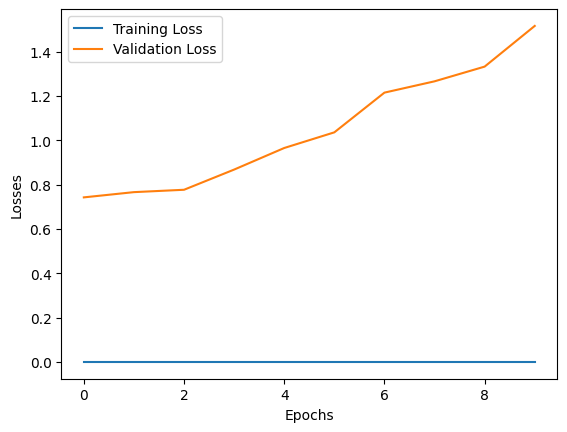

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

#Evaluate the CNN

In [ ]:
correct_labels = 0
total_labels = 0

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        outputs = model.forward(images)
        _, predicted = torch.max(outputs.data, 1)

        total_labels += labels.size(0)
        correct_labels += (predicted == labels).sum().item()

print(f"Accuracy = {100 * correct_labels / total_labels}%")

Accuracy = 73.72%
